pip uninstall torch torchvision
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
pip install -q transformers diffusers accelerate diffusers ipywidgets

In [1]:
import torch
import requests
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from torchvision import transforms as tfms
from transformers import AutoProcessor, Blip2ForConditionalGeneration
from typing import Union, Tuple, Optional
from PIL import Image
from diffusers import StableDiffusionPipeline, DDIMInverseScheduler, AutoencoderKL, DDIMScheduler

/run/media/mulen/2tb nvme/FakeInversion/.fakeinversion/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

original_image =Image.open('./poike.png')

cuda


# Blip 2 captioning


In [3]:

processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16) #float16 to save memory

model.to(device)

inputs = processor(original_image, return_tensors="pt").to(device, torch.float16)

image_caption_embedding = model.generate(**inputs, max_new_tokens=20)
generated_text = processor.batch_decode(image_caption_embedding, skip_special_tokens=True)[0].strip()
print(generated_text)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.97s/it]


two pots of food on a fire


## Feature Extraxtion

In [4]:
#Code inspired by shaibagon on githhub and altered for our use:
# https://github.com/shaibagon/diffusers_ddim_inversion/blob/main/ddim_inversion.py
# under CC liscense 


def load_image(imgname: str, target_size: Optional[Union[int, Tuple[int, int]]] = None) -> torch.Tensor:
    pil_img = Image.open(imgname).convert('RGB')
    if target_size is not None:
        if isinstance(target_size, int):
            target_size = (target_size, target_size)
        pil_img = pil_img.resize(target_size, Image.Resampling.LANCZOS)
    return tfms.ToTensor()(pil_img)[None, ...]  # add batch dimension


def img_to_latents(x: torch.Tensor, vae: AutoencoderKL):
    x = 2. * x - 1.
    posterior = vae.encode(x).latent_dist
    latents = posterior.mean * 0.18215 #could get thsi from the vae passed in?
    return latents

def latent_to_img(latents: torch.Tensor, vae: AutoencoderKL) -> Image.Image:
    latents = latents / 0.18215  # undo scaling #could get thsi from the vae passed in?
    decoded = vae.decode(latents).sample  # [-1,1]
    decoded = (decoded / 2 + 0.5).clamp(0, 1)  # [0,1]
    img = decoded.cpu().permute(0, 2, 3, 1).numpy()[0]  # (H,W,C)
    img = (img * 255).round().astype("uint8")
    return Image.fromarray(img)


@torch.no_grad()
def ddim_inversion_reconstruction(imgname: str, num_steps: int = 50, verify: Optional[bool] = False) -> torch.Tensor:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    dtype = torch.float16

    inverse_scheduler = DDIMInverseScheduler.from_pretrained('runwayml/stable-diffusion-v1-5', subfolder='scheduler')
    
    pipe = StableDiffusionPipeline.from_pretrained('runwayml/stable-diffusion-v1-5',
                                                   scheduler=inverse_scheduler,
                                                   safety_checker=None,
                                                   torch_dtype=dtype)
    pipe.to(device)
    vae = pipe.vae

    input_img = load_image(imgname).to(device=device, dtype=dtype)

    latents = img_to_latents(input_img, vae)

    inv_latents, _ = pipe(prompt="two pots of food on a fire", negative_prompt="", guidance_scale=1.,
                          width=input_img.shape[-1], height=input_img.shape[-2],
                          output_type='latent', return_dict=False,
                          num_inference_steps=num_steps, latents=latents)
    
    inverted_image = latent_to_img (inv_latents, vae)
    
    #Set scheduler to normal forward shedualre to reconstruct image from latens
    pipe.scheduler = DDIMScheduler.from_pretrained('runwayml/stable-diffusion-v1-5', subfolder='scheduler')

    reconstructed_image = pipe(prompt="two pots of food on a fire", negative_prompt="", guidance_scale=1.,
                     num_inference_steps=num_steps, latents=inv_latents).images[0]
    
    return inv_latents, inverted_image, reconstructed_image

In [5]:
inverted_latents , inverted_image , reconstructed_image = ddim_inversion_reconstruction('./poike.png', num_steps=50, verify=False)

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  4.02it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████| 50/50 [00:01<00:00, 25.57it/s]


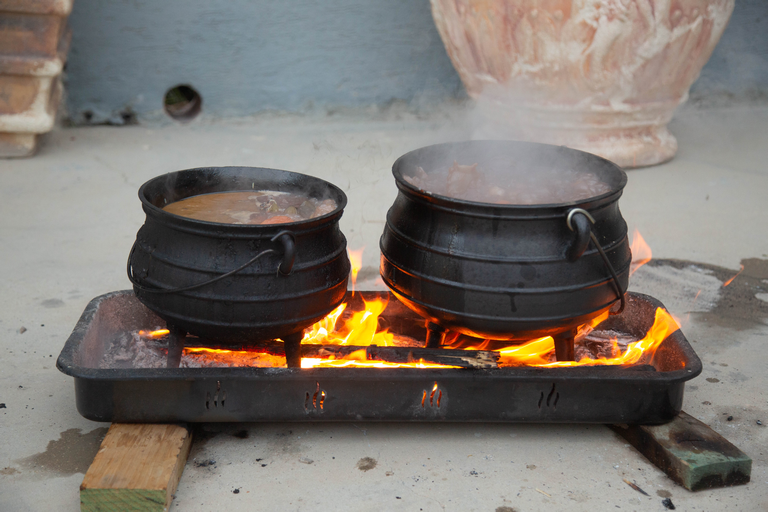

In [6]:

original_image

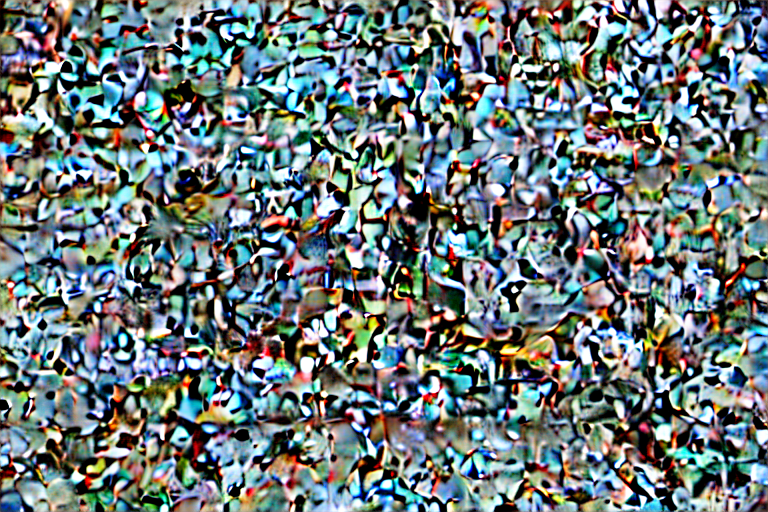

In [7]:
inverted_image

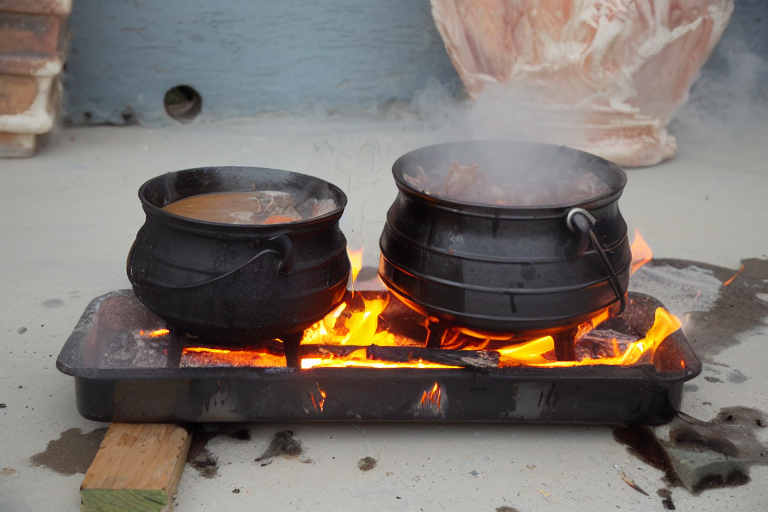

In [8]:
reconstructed_image

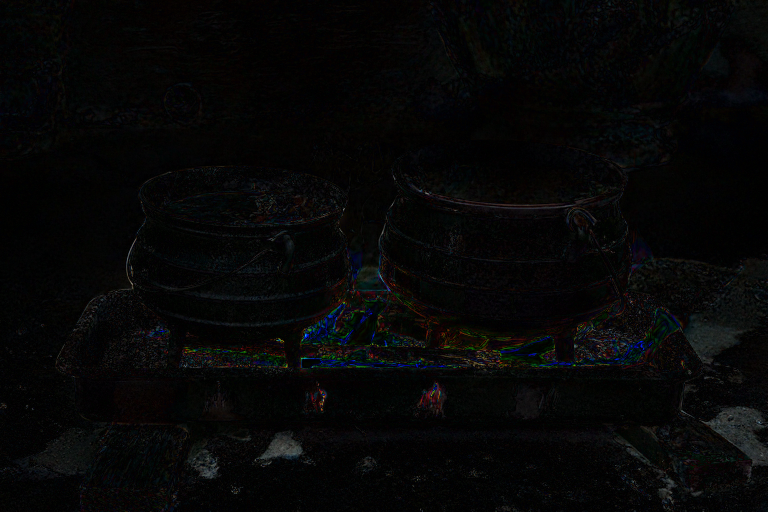

In [9]:
import numpy as np
residual_image = Image.fromarray(
            np.abs(np.asarray(reconstructed_image, dtype=np.float32) - np.asarray(original_image, dtype=np.float32)).astype(
                np.uint8))

residual_image

# Resnet50 classifer